## ВВЕДЕНИЕ

Профиль: «DevOps-инженерия»
1. Тема проекта: «Разработка и автоматизация пайплайна машинного обучения для решения задачи бинарной классификации»
2. Цель проекта: закрепление на практике компетенций по сбору, обработке и анализу данных, построению, оценке и улучшению моделей машинного обучения, а также освоение принципов DevOps (MLOps) для автоматизации процесса.
3. Задача на проект: разработать сквозной (end-to-end) пайплайн машинного обучения на языке Python, который решает задачу бинарной классификации на публичном датасете с платформы Kaggle (объемом не менее 5000 записей). Пайплайн должен включать этапы: обработки данных (EDA, Feature Engineering), тренировки нескольких моделей, их валидации и сравнения, а также оформления в виде воспроизводимого кода (ноутбук Jupyter/Lab или Python-скрипты), готового к автоматизации.


## РОЛИ

Роль №1: Data Scientist / Researcher \
Фокус: Исследование данных, feature engineering, подбор и тренировка моделей, их оценка и интерпретация. \
Основные задачи: \
1.	Выбор и загрузка датасета с Kaggle. \
2.	Проведение разведочного анализа данных (EDA): визуализация распределений, анализ пропусков, выбросов, корреляций. \
3.	Предобработка данных: обработка пропусков, кодирование категориальных переменных, масштабирование числовых признаков. \
4.	Разделение данных на тренировочную и тестовую выборки. \
5.	Обучение как минимум 3-х различных моделей (например, Logistic Regression, Random Forest, Gradient Boosting (XGBoost/LightGBM/CatBoost)). \
6.	Оценка моделей на кросс-валидации и тестовой выборке с использованием метрик: Accuracy, Precision, Recall, F1-score, ROC-AUC. \
7.	Интерпретация результатов: анализ важности признаков, матрица ошибок. \
8.	Написание выводов по каждому этапу.


Роль №2: ML Engineer / DevOps Engineer \
Фокус: Инженерия кода, воспроизводимость, автоматизация, документирование, подготовка к deployment. \
Основные задачи: \
1.	Организация кодовой базы: создание структурированного репозитория (например, на GitHub). \
2.	Настройка виртуального окружения и фиксация версий пакетов (requirements.txt или environment.yml). \
3.	Рефакторинг кода исследования: разбиение на логические блоки/функции для улучшения читаемости. \
4.	Написание модульных тестов для ключевых функций (например, функций предобработки). \
5.	Настройка инструментов для обеспечения качества кода (например, flake8, black — линтинг и форматирование). \
6.	Создание простого пайплайна автоматизации с помощью dvc (Data Version Control) или скриптов для воспроизведения всех этапов (скачивание данных -> предобработка -> обучение -> оценка) одной командой. \
7.	Документирование проекта: README.md с описанием задачи, инструкцией по запуску и выводов.


## ВЫПОЛНЕНИЕ РАБОТЫ

### Этап 0. Организационный

o	Выбор датасета и его краткий анализ. \
o	Распределение ролей в команде. \
o	Создание репозитория GitHub, настройка окружения.


#### Импорты

In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\choko\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set(style="whitegrid")


In [17]:
path = "PycharmProjects/loan-pipeline/data/loan_default_raw.csv"  
print("shape:", df.shape)
display(df.head())


shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [19]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

None

In [20]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LoanID,255347,255347,ZTH91CGL0B,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,255347.0,NaN,NaN,NaN,43.498306,14.990258,18.0,31.0,43.0,56.0,69.0
Income,255347.0,NaN,NaN,NaN,82499.304597,38963.013729,15000.0,48825.5,82466.0,116219.0,149999.0
LoanAmount,255347.0,NaN,NaN,NaN,127578.865512,70840.706142,5000.0,66156.0,127556.0,188985.0,249999.0
CreditScore,255347.0,NaN,NaN,NaN,574.264346,158.903867,300.0,437.0,574.0,712.0,849.0
MonthsEmployed,255347.0,NaN,NaN,NaN,59.541976,34.643376,0.0,30.0,60.0,90.0,119.0
NumCreditLines,255347.0,NaN,NaN,NaN,2.501036,1.117018,1.0,2.0,2.0,3.0,4.0
InterestRate,255347.0,NaN,NaN,NaN,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,NaN,NaN,NaN,36.025894,16.96933,12.0,24.0,36.0,48.0,60.0
DTIRatio,255347.0,NaN,NaN,NaN,0.500212,0.230917,0.1,0.3,0.5,0.7,0.9


In [21]:
miss = df.isnull().sum().sort_values(ascending=False)
display(miss[miss>0])

Series([], dtype: int64)

Target distribution:
 Default
0    225694
1     29653
Name: count, dtype: int64


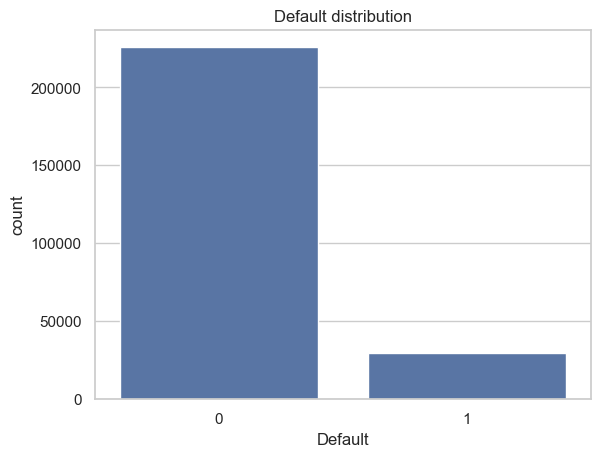

In [22]:
print("Target distribution:\n", df['Default'].value_counts())
sns.countplot(x='Default', data=df)
plt.title("Default distribution")
plt.show()


### Этап 1: Исследование и предобработка данных (Data Scientist-led) 

o	Грубая EDA, анализ пропусков, выбросов.\
o	Разработка стратегии предобработки.\
o	Кодирование, масштабирование, очистка.\
o	Фиксация результатов в Jupyter-ноутбуке

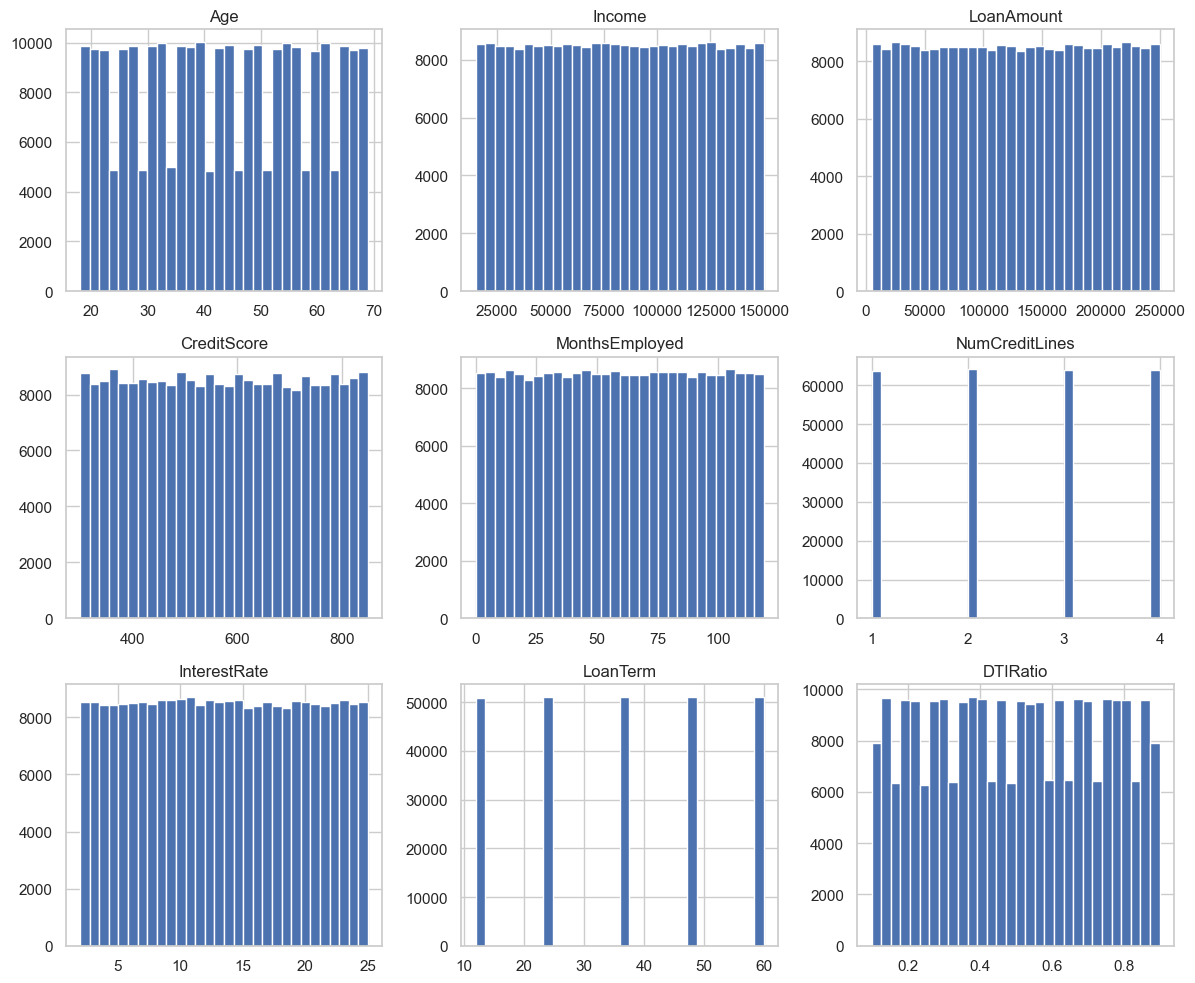

In [23]:
num_cols = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines','InterestRate','LoanTerm','DTIRatio']
cat_cols = ['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

df[num_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()


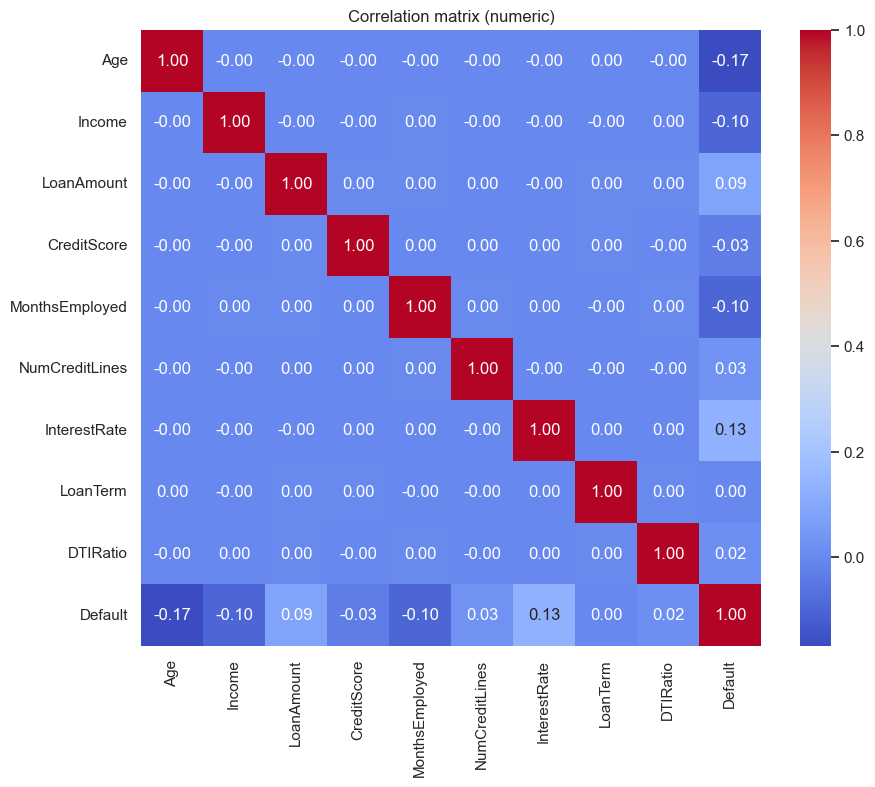

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols + ['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation matrix (numeric)")
plt.show()

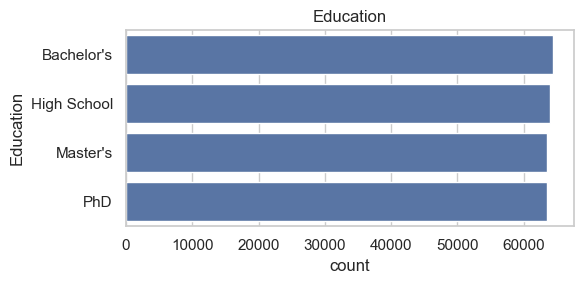

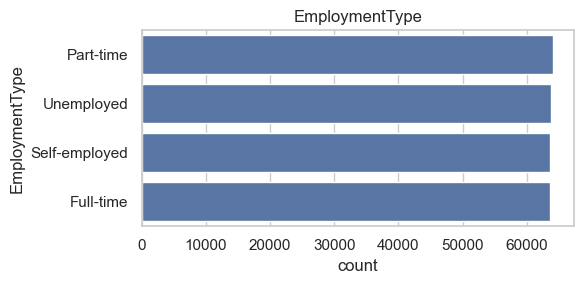

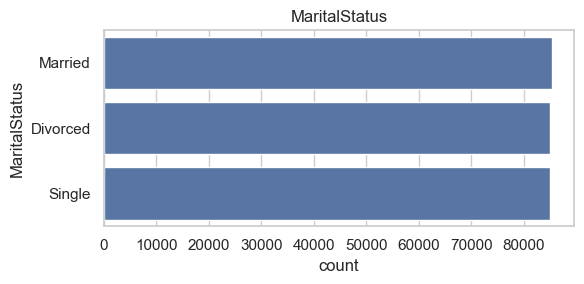

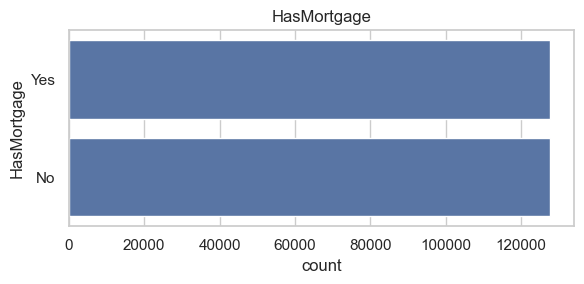

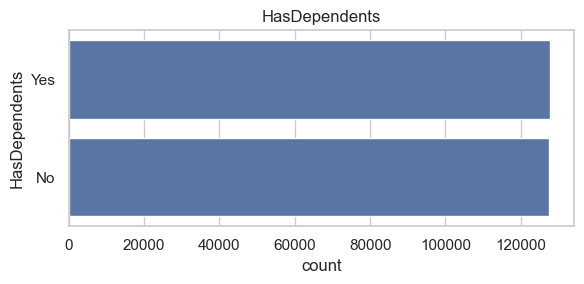

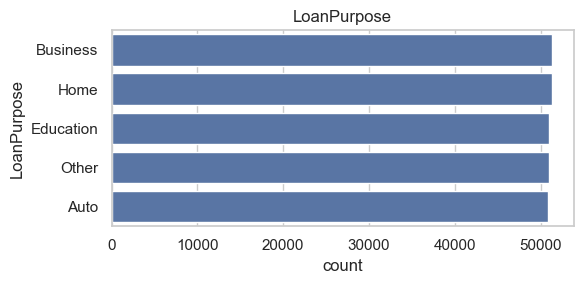

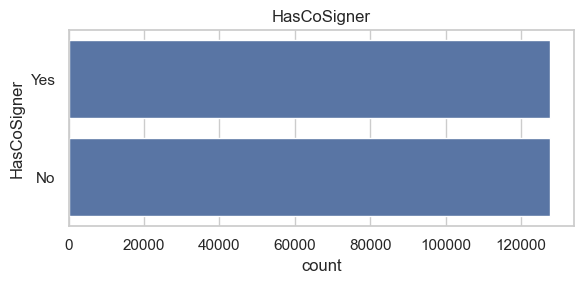

In [25]:
for c in cat_cols:
    if c in df.columns:
        plt.figure(figsize=(6,3))
        sns.countplot(y=c, data=df, order=df[c].value_counts().index[:20])
        plt.title(c)
        plt.tight_layout()
        plt.show()

In [30]:
edu_map = {"High School":1, "Bachelor's":2, "Master's":3, "PhD":4}
empl_map = {"Part-time":1, "Unemployed":2, "Self-employed":3, "Full-time":4}
mar_map = {"Married":1, "Divorced":2, "Single":3}
purp_map = {"Business":1, "Home":2, "Education":3, "Auto":4, "Other":5}

In [31]:
df_p = df.copy()

if 'LoanID' in df_p.columns:
    df_p = df_p.drop(columns=['LoanID'])

for c in ['HasMortgage','HasDependents','HasCoSigner']:
    if c in df_p.columns:
        df_p[c] = df_p[c].map({'Yes':1, 'No':0})

df_p['Education_ord'] = df_p['Education'].map(edu_map)
df_p['EmploymentType_ord'] = df_p['EmploymentType'].map(empl_map)
df_p['MaritalStatus_ord'] = df_p['MaritalStatus'].map(mar_map)
df_p['LoanPurpose_ord'] = df_p['LoanPurpose'].map(purp_map)


if set(['LoanAmount','Income']).issubset(df_p.columns):
    df_p['loan_to_income'] = df_p['LoanAmount'] / (df_p['Income'].replace(0, np.nan))
    

display(df_p.head())


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Education_ord,EmploymentType_ord,MaritalStatus_ord,LoanPurpose_ord,loan_to_income
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,...,1,1,Other,1,0,2,4,2,5,0.588262
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,...,0,0,Other,1,0,3,4,1,5,2.467481
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,...,1,1,Auto,0,1,3,2,2,4,1.534154
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,...,0,0,Business,0,0,1,4,1,1,1.412638
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,...,0,1,Auto,0,0,2,2,2,4,0.447179


In [32]:
numeric_cols = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines','InterestRate','LoanTerm','DTIRatio','loan_to_income','Education_ord']
numeric_cols = [c for c in numeric_cols if c in df_p.columns]

categorical_cols = [c for c in ['EmploymentType','MaritalStatus','LoanPurpose'] if c in df_p.columns]
binary_cols = [c for c in ['HasMortgage','HasDependents','HasCoSigner'] if c in df_p.columns]

# Итоговые признаки:
feature_cols = numeric_cols + binary_cols + categorical_cols
print("numeric:", numeric_cols)
print("binary:", binary_cols)
print("categorical:", categorical_cols)

numeric: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'loan_to_income', 'Education_ord']
binary: ['HasMortgage', 'HasDependents', 'HasCoSigner']
categorical: ['EmploymentType', 'MaritalStatus', 'LoanPurpose']


###	Этап 2: Построение и оценка моделей (Data Scientist-led) 

o	Обучение базовых моделей.\
o	Сравнение метрик, подбор гиперпараметров (GridSearchCV/RandomizedSearchCV) для лучшей модели.\
o	Анализ важности признаков.

In [33]:
X = df_p[feature_cols]
y = df_p['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("train/test shapes:", X_train.shape, X_test.shape)

train/test shapes: (204277, 17) (51070, 17)


In [35]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
], remainder='passthrough')  # passthrough

# с логистической регрессией
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])


In [36]:
# Модель StratifiedKFold
scoring = ['accuracy','precision','recall','f1','roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_res = cross_validate(pipe_lr, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)
pd.DataFrame(cv_res).mean()


fit_time          1.078705
score_time        0.166434
test_accuracy     0.886571
test_precision    0.604454
test_recall       0.067237
test_f1           0.120999
test_roc_auc      0.755867
dtype: float64

In [38]:
# Cell 8: final eval on test set
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070

ROC AUC: 0.7616722887655859


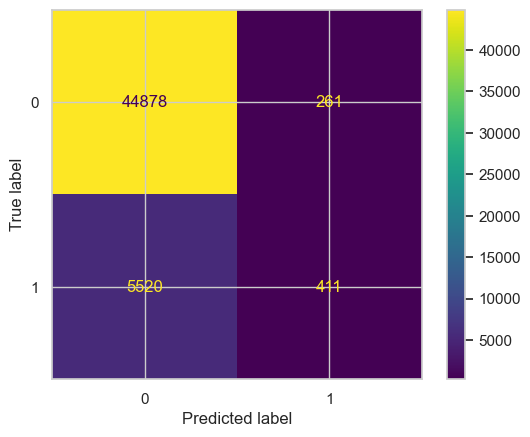

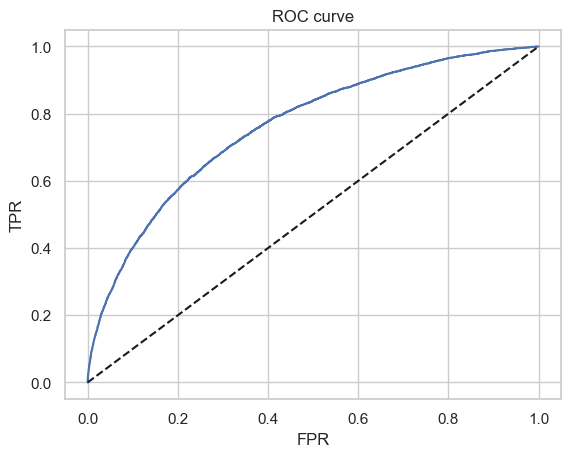

In [39]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve')
plt.show()


In [40]:
#Модель RandomForestClassifier
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 6, 12, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': [None, 'balanced']
}

rs = RandomizedSearchCV(rf_pipe, param_distributions=param_dist, n_iter=20, scoring='roc_auc', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
rs.fit(X_train, y_train)

print("Best ROC-AUC (CV):", rs.best_score_)
print("Best params:", rs.best_params_)
best_rf = rs.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best ROC-AUC (CV): 0.74772983615245
Best params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_depth': 12, 'clf__class_weight': 'balanced'}


In [41]:
# Cell 10: feature names + importances
# получить имена из preprocessor
pre = best_rf.named_steps['preprocessor']
# numeric names:
num_names = numeric_cols
# onehot names (если есть категориальные)
cat_ohe_names = []
if len(categorical_cols) > 0:
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    cat_ohe_names = list(ohe.get_feature_names_out(categorical_cols))

feature_names = num_names + cat_ohe_names
len(feature_names), feature_names[:30]

(23,
 ['Age',
  'Income',
  'LoanAmount',
  'CreditScore',
  'MonthsEmployed',
  'NumCreditLines',
  'InterestRate',
  'LoanTerm',
  'DTIRatio',
  'loan_to_income',
  'Education_ord',
  'EmploymentType_Full-time',
  'EmploymentType_Part-time',
  'EmploymentType_Self-employed',
  'EmploymentType_Unemployed',
  'MaritalStatus_Divorced',
  'MaritalStatus_Married',
  'MaritalStatus_Single',
  'LoanPurpose_Auto',
  'LoanPurpose_Business',
  'LoanPurpose_Education',
  'LoanPurpose_Home',
  'LoanPurpose_Other'])

In [48]:
X_transformed = best_rf.named_steps['preprocessor'].transform(X_test)
print("Форма после препроцессинга:", X_transformed.shape)

Форма после препроцессинга: (51070, 26)


In [49]:
preprocessor = best_rf.named_steps['preprocessor']

# числовые
num_features = numeric_cols  

# категориальные после OneHotEncoder
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)

# остаточные (если remainder='passthrough')
passthrough_features = []
if preprocessor.remainder == 'passthrough':
    passthrough_features = preprocessor.transformers_[-1][-1]  # индексы колонок
    if isinstance(passthrough_features, slice):
        passthrough_features = df.columns[passthrough_features]
    elif all(isinstance(x, int) for x in passthrough_features):
        passthrough_features = df.columns[list(passthrough_features)]

# собираем финальный список
feature_names = list(num_features) + list(cat_features) + list(passthrough_features)

print("Число фичей:", len(feature_names))
print("Число importances:", len(importances))

Число фичей: 26
Число importances: 26


In [50]:

# Теперь важности
importances = best_rf.named_steps['clf'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

display(feat_imp.head(30))


,feature,importance
0,Age,0.214121
6,InterestRate,0.161293
9,loan_to_income,0.133430
4,MonthsEmployed,0.097693
1,Income,0.093677
2,LoanAmount,0.072203
3,CreditScore,0.052870
8,DTIRatio,0.041281
5,NumCreditLines,0.015093
10,Education_ord,0.015007


In [52]:
os.makedirs('PycharmProjects/loan-pipeline/models', exist_ok=True)
joblib.dump(best_rf, 'PycharmProjects/loan-pipeline/models/best_rf_pipeline.joblib')
print("Saved to PycharmProjects/loan-pipeline/models/best_rf_pipeline.joblib")

Saved to PycharmProjects/loan-pipeline/models/best_rf_pipeline.joblib


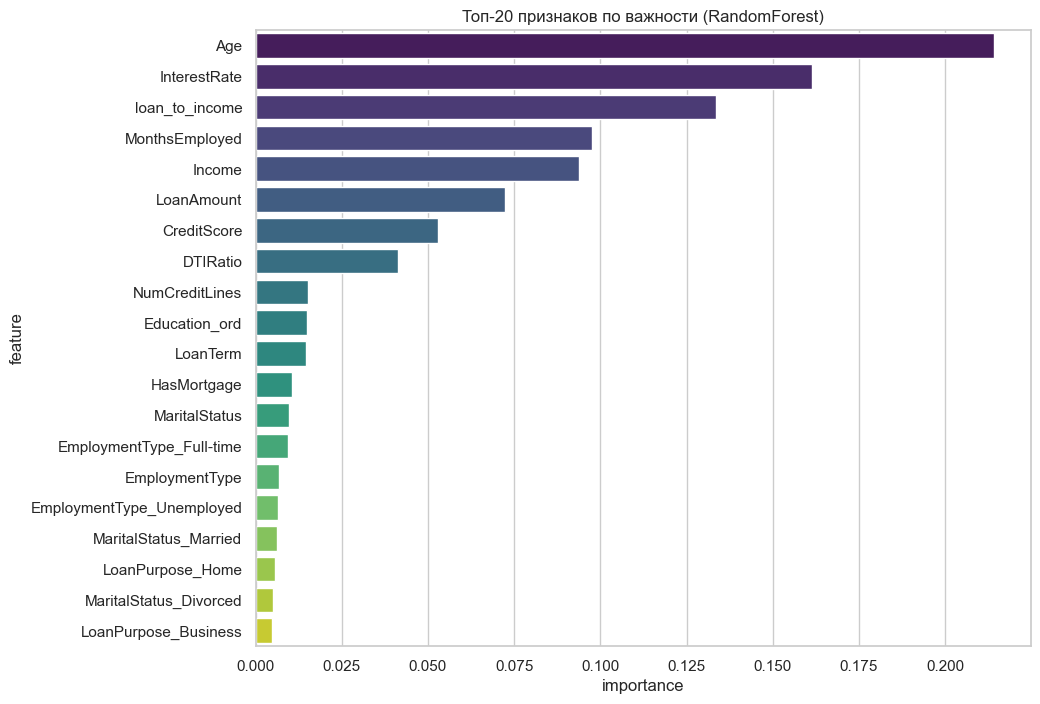

In [53]:
plt.figure(figsize=(10,8))
sns.barplot(x="importance", y="feature", 
            data=feat_imp.head(20), palette="viridis")
plt.title("Топ-20 признаков по важности (RandomForest)")
plt.show()


In [55]:
feature_names

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'loan_to_income',
 'Education_ord',
 'EmploymentType_Full-time',
 'EmploymentType_Part-time',
 'EmploymentType_Self-employed',
 'EmploymentType_Unemployed',
 'MaritalStatus_Divorced',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'LoanPurpose_Auto',
 'LoanPurpose_Business',
 'LoanPurpose_Education',
 'LoanPurpose_Home',
 'LoanPurpose_Other',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage']

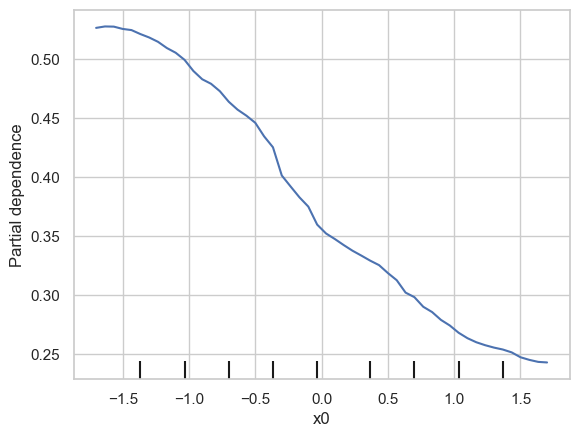

In [59]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_rf.named_steps['clf'], 
    X_transformed, 
    [feature_names.index('Age')]
)
plt.show()

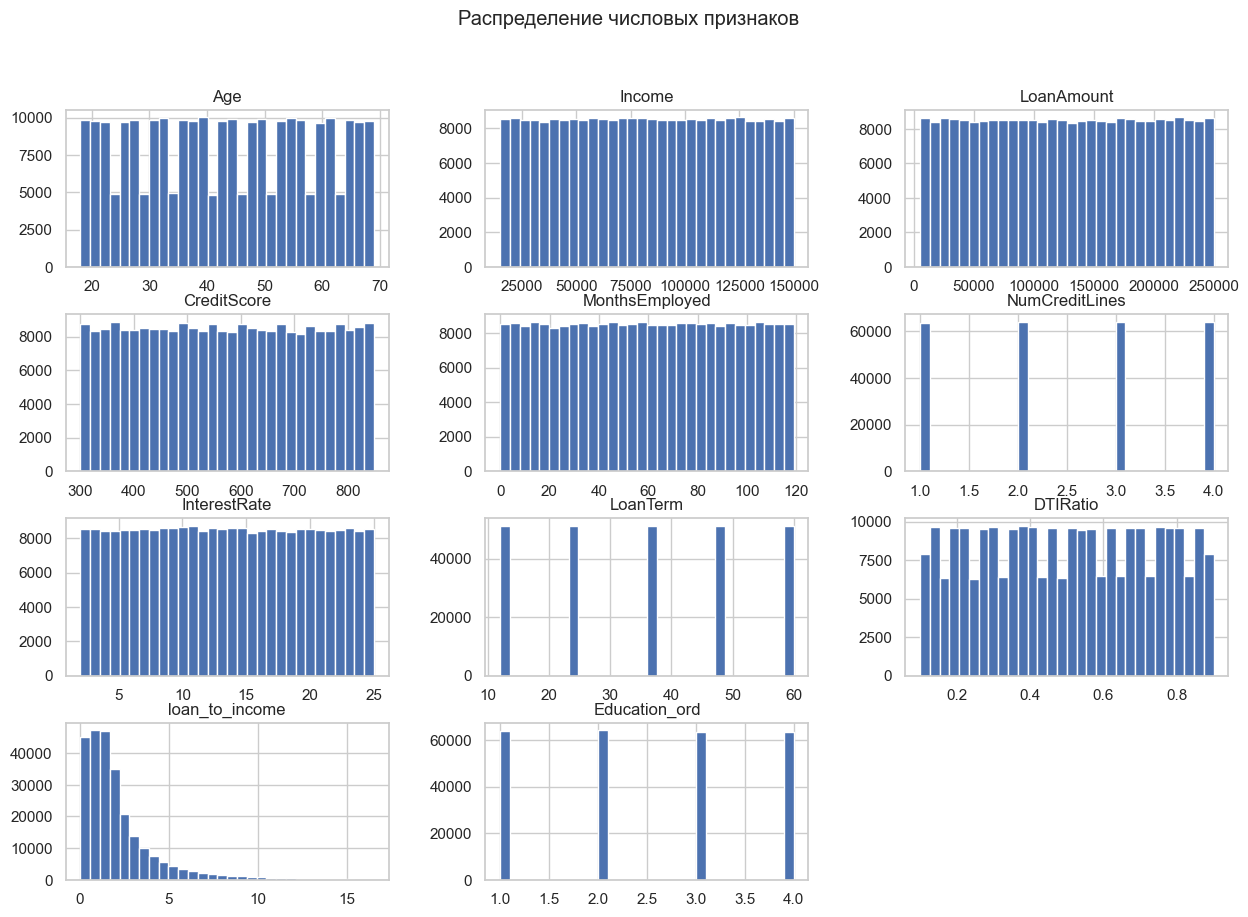

In [62]:
df_p[numeric_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Распределение числовых признаков")
plt.show()

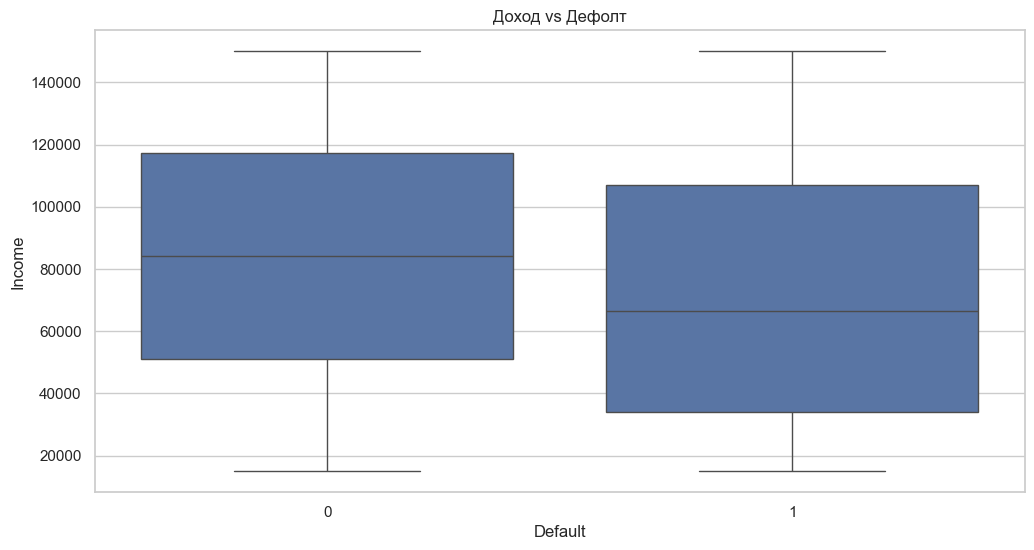

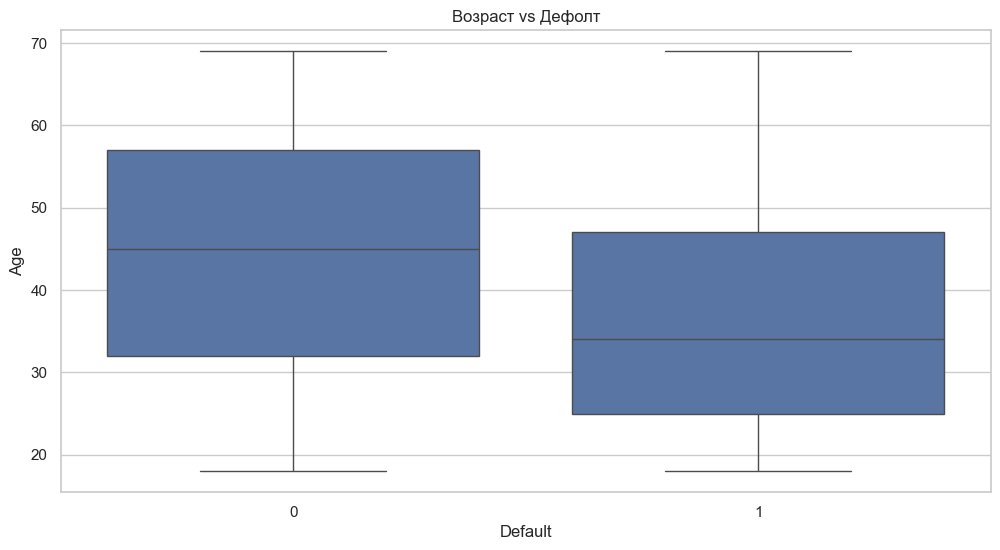

In [63]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_p, x="Default", y="Income")
plt.title("Доход vs Дефолт")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df_p, x="Default", y="Age")
plt.title("Возраст vs Дефолт")
plt.show()


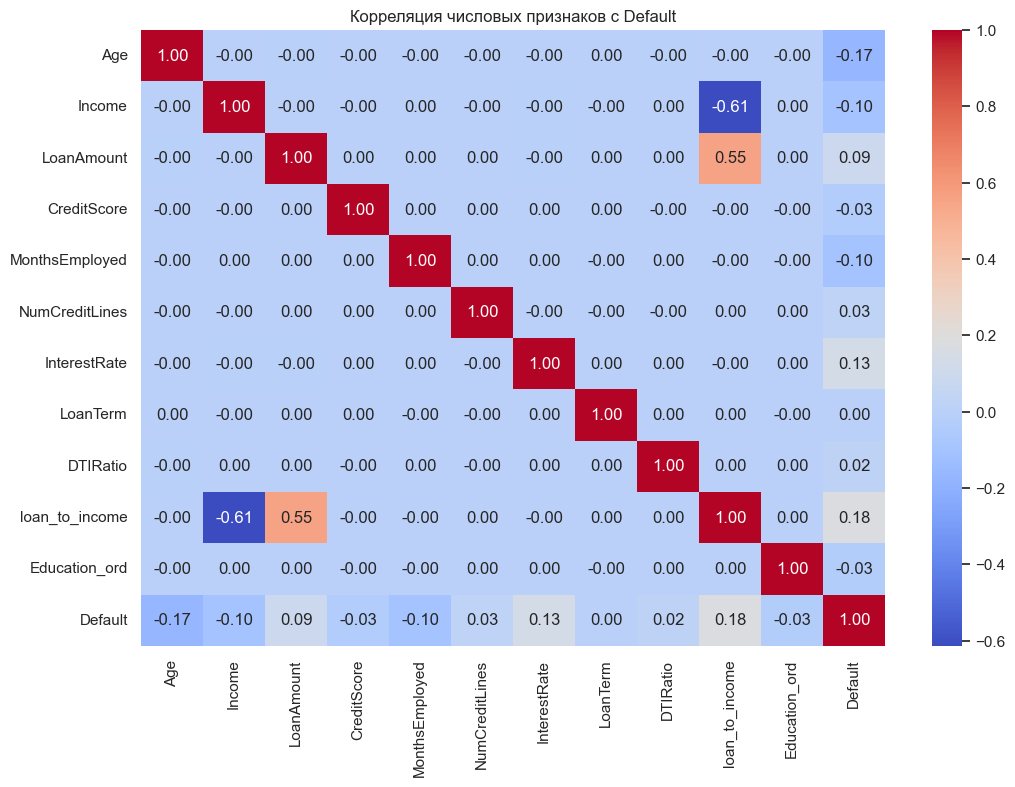

In [64]:
plt.figure(figsize=(12,8))
corr = df_p[numeric_cols + ["Default"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция числовых признаков с Default")
plt.show()

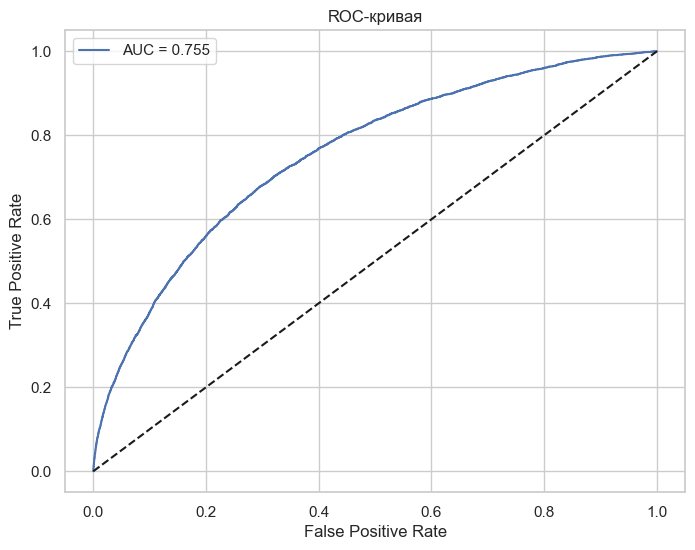

In [65]:
y_pred_proba = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()


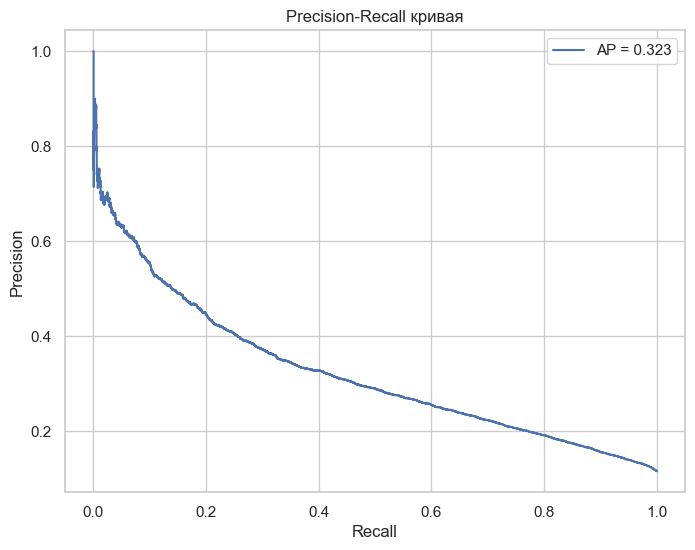

In [67]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая")
plt.legend()
plt.show()


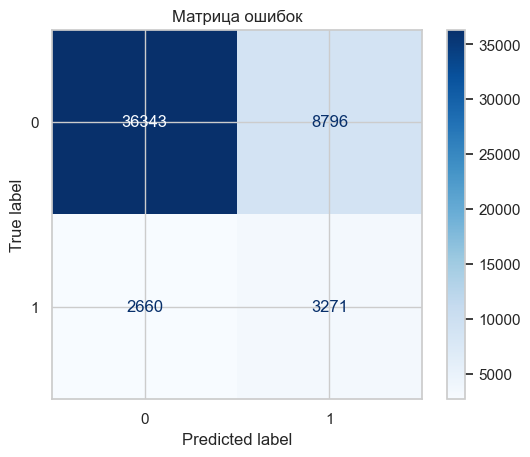

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues")
plt.title("Матрица ошибок")
plt.show()


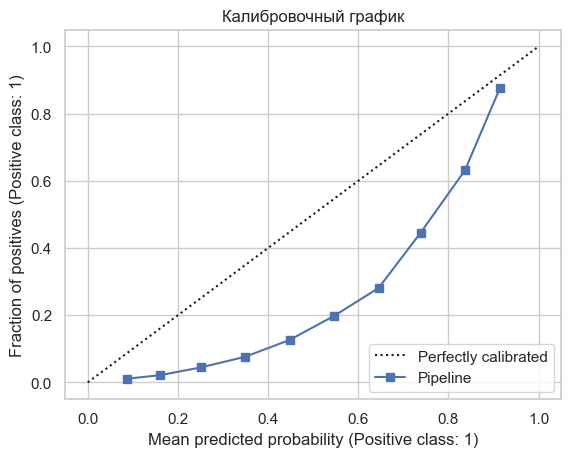

In [69]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(best_rf, X_test, y_test, n_bins=10)
plt.title("Калибровочный график")
plt.show()


In [74]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 4.2 MB/s eta 0:00:14
    --------------------------------------- 0.8/56.8 MB 5.6 MB/s eta 0:00:11
   - -------------------------------------- 2.1/56.8 MB 4.2 MB/s eta 0:00:14
   - -------------------------------------- 2.4/56.8 MB 3.4 MB/s eta 0:00:17
   -- ------------------------------------- 3.1/56.8 MB 3.3 MB/s eta 0:00:17
   -- ------------------------------------- 3.9/56.8 MB 3.5 MB/s eta 0:00:16
   --- ------------------------------------ 5.0/56.8 MB 3.6 MB/s eta 0:00:15
   ---- ----------------------------------- 6.3/56.8 MB 3.9 MB/s eta 0:00:14
   ---- ----------------------------------- 6.8/56.8 MB 3.7 MB/s eta 0:00:14
   ----- ---------------------------------- 7.6/56.8 MB 3.7 MB/s eta 0:00:14
   ----- ---------------------------------- 8.4/56.8 MB 3.7 MB/s eta 0:00:13
   ------ --------------------------------- 9.4/56.8 MB 3.8 MB/s eta 0:00:13
   ---


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\choko\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ))
])

param_grid_xgb = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.1, 0.05],
    'clf__subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("Лучшие параметры XGBoost:", grid_xgb.best_params_)

# Оценка на тесте
y_pred_xgb = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))


Лучшие параметры XGBoost: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.58      0.08      0.13      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.53      0.54     51070
weighted avg       0.86      0.89      0.85     51070



### Этап 3: Инженерия и автоматизация (ML Engineer-led) 

o	Рефакторинг кода: создание функций предобработки, обучения, оценки.\
o	Написание тестов.\
o	Настройка DVC для управления данными и моделью или написание скриптов.\
o	Оформление README.md.


### Этап 4: Финальный анализ и оформление отчета (совместно)

o	Совместное обсуждение результатов.\
o	Подготовка финальной презентации или отчета (не менее 10 слайдов/страниц).\
o	Формулировка выводов: какая модель показала лучший результат и почему, какие признаки наиболее значимы, какие гипотезы были проверены и подтверждены/опровергнуты.